In [ ]:
#swiggy sales analysis
#importing libraries
import pandas as pd  #used for data manupulation and analysis(like orking with tabls/dataframes)
import numpy as np   #used for numerical operations(arrays,mathematical calculation)
import matplotlib.pyplot as plt  #used for creating basic satatistical charts and graphs
import seaborn as sns   #used for advanced and more attractive statistical visualisation
import plotly.express as px  #used for create interactive charts(zoom,hover,dynamic visuals)

In [ ]:
df=pd.read_excel("/content/swiggy_data.xlsx")
df.head(10)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0
5,Karnataka,Bengaluru,2025-07-08,Srinidhi Sagar Deluxe,Kengeri,Recommended,Srinidhi Sagar Special,312.0,4.0,0
6,Karnataka,Bengaluru,2025-01-21,Srinidhi Sagar Deluxe,Kengeri,Recommended,Garlic Naan,98.0,4.0,34
7,Karnataka,Bengaluru,2025-04-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Pista,137.0,4.0,0
8,Karnataka,Bengaluru,2025-05-02,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Panneer Butter Masala,241.0,4.4,29
9,Karnataka,Bengaluru,2025-07-30,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Dal Tadka,195.0,4.9,51


In [ ]:
df.tail(5) #to see last 5 rows

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


In [ ]:
#to see the shape of the data number of rows in data
print("no.of rows",df.shape[0])

no.of rows 197430


In [ ]:
#to see the shape of the data no.of columns
print("no.of.coloumn",df.shape[1])

no.of.coloumn 10


In [ ]:
#checking datatype
df.dtypes

,0
State,object
City,object
Order Date,datetime64[ns]
Restaurant Name,object
Location,object
Category,object
Dish Name,object
Price (INR),float64
Rating,float64
Rating Count,int64


In [ ]:
df.describe() #if you want to check mean,median,mode,max,min

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


In [ ]:
#total sales checking
totalsales=df["Price (INR)"].sum()
print("totalsales",round(totalsales)) #using round fn for rounding of the number

totalsales 53012506


In [ ]:
averagerate=df["Rating"].mean() #avg rate
print("avg rate",round(averagerate,2))

avg rate 4.34


In [ ]:
#avg order value
avg_order_value=df["Price (INR)"].mean()
print("order value",round(avg_order_value,2))

order value 268.51


In [ ]:
# rating count
rating_count=df["Rating Count"].sum()
print("rating count",rating_count)

rating count 5591574


In [ ]:
# len-remove duplicates
total_order=len(df)
print("Total_orders:",round(total_order))

Total_orders: 197430


In [ ]:
total_order=df.count()
print("Total_orders:",round(total_order))

Total_orders: State              197430
City               197430
Order Date         197430
Restaurant Name    197430
Location           197430
Category           197430
Dish Name          197430
Price (INR)        197430
Rating             197430
Rating Count       197430
dtype: int64


In [ ]:
#monthly sales data


<function matplotlib.pyplot.show(close=None, block=None)>

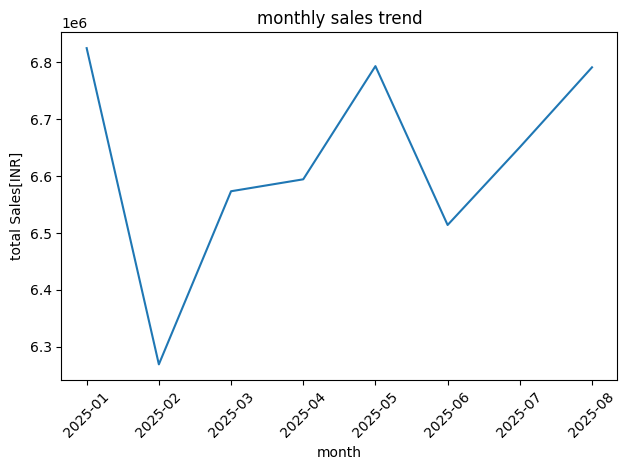

In [ ]:
#convert 'order date' column to datetime format(important for data operations)
df["Order Date"]=pd.to_datetime(df["Order Date"])

#extract year and month from "orde date"(format:yyy-mmm like 2025-01)
df["yearmonth"]=df["Order Date"].dt.to_period("M").astype(str)

#group data by yearmonth and calculate total revenue for each month
monthly_revenue=df.groupby("yearmonth")["Price (INR)"].sum().reset_index()

#create a new figure for plotting
plt.figure()

#plot line chart:x axis=month,y axis=total sales
plt.plot(monthly_revenue["yearmonth"],monthly_revenue["Price (INR)"])

#rotate x axis lables for 45 degree for better redability
plt.xticks(rotation=45)

#lable for x axis
plt.xlabel("month")

#lable for y axis
plt.ylabel("total Sales[INR]")

#title of the chart
plt.title("monthly sales trend")

#adjust layout to prevent label overlap
plt.tight_layout()

#display the plot
plt.show

In [ ]:
#daily sales trend

<function matplotlib.pyplot.show(close=None, block=None)>

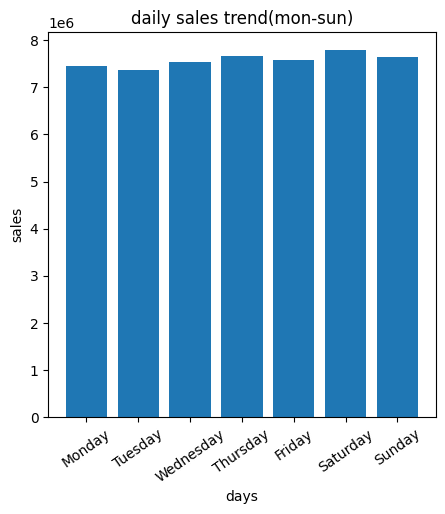

In [ ]:
#extract day name(mon,tuesday,wed etc...)
df["dayname"]=pd.to_datetime(df["Order Date"]).dt.day_name()
#group data by name and calculate total rev for each day
dailyrev=df.groupby("dayname")["Price (INR)"].sum().reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
#create a figure with specified size
plt.figure(figsize=(5,5))
#create a bar chart:x axis=days,y axis=sales
plt.bar(dailyrev.index,dailyrev.values)
#title of the chart
plt.title("daily sales trend(mon-sun)")
#label for axis
plt.xlabel("days")
plt.ylabel("sales")
#rotation 35
plt.xticks(rotation=35)
#display
plt.show




In [ ]:
#total sales by veg and non veg
#creating a list of keywords that indicates non_veg items
non_veg_keywords=["egg","fish","chicken","mutton","prawn","biryani","kebab","non_veg","non veg"]

#creat a new column 'foodcategory' based on dish name
df["foodcategory"]=np.where(df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords),na=False),"non_veg","veg")

In [ ]:
#calculate total rev for veg and non veg categories
food_rev=(df.groupby("foodcategory")["Price (INR)"].sum().reset_index())

In [ ]:
import plotly.express as px  #used for create interactive charts(zoom,hover,dynamic visuals)

In [ ]:
 #create a donut pie chart
fig=px.pie(
     food_rev,
     values="Price (INR)",
     names="foodcategory",
     hole=0.5,
     title="revenue contribution:veg vs non_veg")

 #customize slices
fig.update_traces(
     textinfo="percent+label",
     pull=[0.05,0])

#adjust layout settings
fig.update_layout(
    height=500,
    margin=dict(t=30,b=0,l=0,r=0))

#show the interactive chart
fig.show()


In [ ]:
#total  sales by  state
#create a horizontal  bar chart
fig=px.bar(
    df.groupby("State",as_index=False)["Price (INR)"].sum().sort_values("Price (INR)",ascending=False),
    x='Price (INR)',
    y="State",
    orientation="h",
    title="Revenue(INR) by  State"
)
#customize  layout
fig.update_layout(
    height=600,
    yaxis=
    dict(autorange="reversed")
)
fig.show()






In [ ]:

#convert  "Order  date" column  to  dataframe
df["Order Date"]=pd.to_datetime(df["Order Date"])
#create a new column  "Quarter"(eg.2025Q1,2025Q2)
df["Quarter"]=df["Order Date"].dt.to_period("Q").astype(str)
#create quartely  summary
quartely_summary=(
    df.groupby("Quarter",as_index=False)
.agg(
    total_sales=("Price (INR)","sum"),
    avg_rating=("Rating","mean"),
    total_orders=("Order Date","count"))
.sort_values("Quarter")
)

#Round  total sales to  nearest whole number
quartely_summary["total_sales"]=quartely_summary["total_sales"].round(0)
quartely_summary["avg_rating"]=quartely_summary["avg_rating"].round(2)
quartely_summary



,Quarter,total_sales,avg_rating,total_orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


In [ ]:
#group data by cities
top_5_cities=(
    df.groupby("City")["Price (INR)"]
    .sum()
    .nlargest(5)
    .sort_values(ascending=False)
    .reset_index()
)

#create horizontal bar chart
fig=px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    color="City",
    title="top 5 cities by sales(INR)",
    color_discrete_sequence=[
        "red",
        "blue",
        "green",
        "maroon",
        "pink"
    ]
)

#show chart
fig.show()